### Step 1: Define Business Context and Model Goals

- **Business goal:** - To identify students at risk of failing their courses.
- **Error costs:** - Missing an at-risk student (false negative) is more costly than falsely flagging a student as at-risk (false positive).
- **Primary metric:** - We'll use recall as our primary metric to minimize missed at-risk students.
- **Secondary metrics:** - We'll also track F1 score to ensure a balanced model.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, recall_score


In [27]:
data = pd.read_csv('edu_student_data.csv')

### Step 2: Data Understanding and Exploration

In [28]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   study_hours         450 non-null    float64
 1   previous_scores     460 non-null    float64
 2   attendance          470 non-null    float64
 3   course_difficulty   475 non-null    object 
 4   learning_style      480 non-null    object 
 5   teacher_experience  485 non-null    object 
 6   failed              500 non-null    int64  
dtypes: float64(3), int64(1), object(3)
memory usage: 27.5+ KB


In [29]:
# Examine the data via initial inspection 
print("First few rows of our dataset:")
print(data.head())
print("\nMissing values in each column:")
print(data.isnull().sum())
print("\nClass distribution:")
print(data['failed'].value_counts(normalize=True) * 100)

First few rows of our dataset:
   study_hours  previous_scores  ...  teacher_experience failed
0    17.483571        88.892663  ...              junior      0
1    14.308678       103.641250  ...           mid-level      1
2    18.238443        54.021486  ...              senior      0
3    22.615149        83.444539  ...           mid-level      0
4    13.829233        65.240361  ...                 NaN      0

[5 rows x 7 columns]

Missing values in each column:
study_hours           50
previous_scores       40
attendance            30
course_difficulty     25
learning_style        20
teacher_experience    15
failed                 0
dtype: int64

Class distribution:
failed
0    76.0
1    24.0
Name: proportion, dtype: float64


In [30]:
# ----- EXPLORATORY DATA ANALYSIS -----
print("\n===== COMPREHENSIVE DATA EXPLORATION =====")

# Basic statistical summary
numeric_features = ['study_hours', 'previous_scores', 'attendance']
categorical_features = ['course_difficulty', 'learning_style', 'teacher_experience']
print("\nNumerical feature statistics:")
print(data[numeric_features].describe())


===== COMPREHENSIVE DATA EXPLORATION =====

Numerical feature statistics:
       study_hours  previous_scores  attendance
count   450.000000       460.000000  470.000000
mean     15.134090        75.654872   86.142547
std       4.818028        14.611390   10.242506
min       1.901274        34.546700   56.037446
25%      11.614491        66.347978   78.954464
50%      15.113785        75.438757   86.047883
75%      18.303682        84.694359   93.172590
max      34.263657       114.485731  111.016831


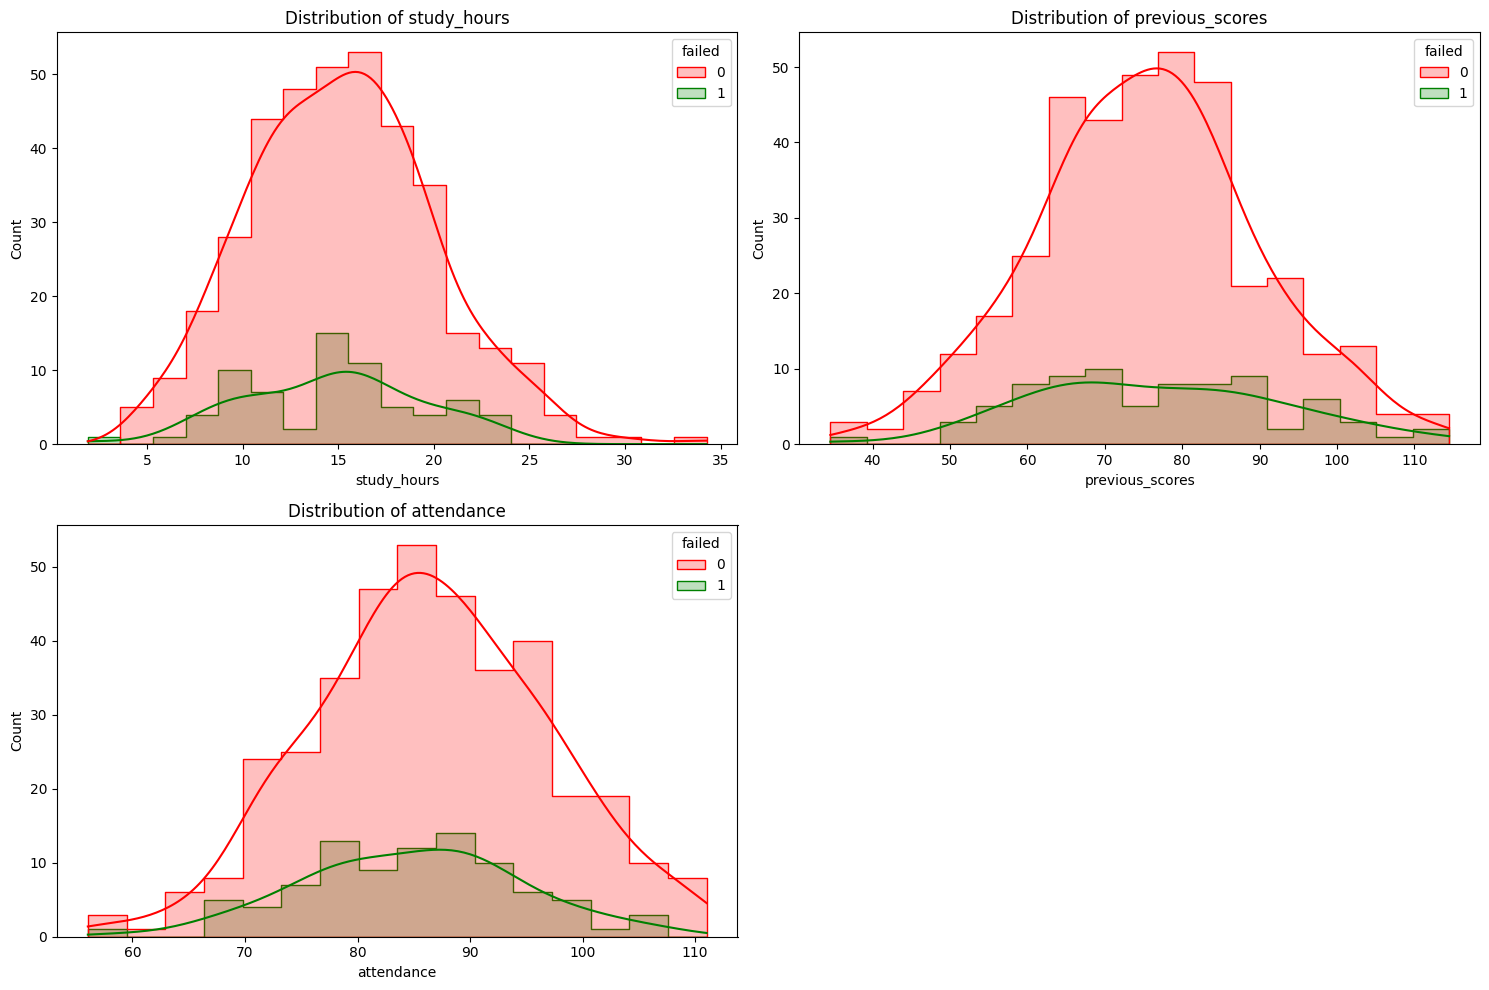

In [31]:
# Examine distribution of each numeric feature
plt.figure(figsize=(15, 10))

# Plot histograms of numerical features
for i, feature in enumerate(numeric_features):
    plt.subplot(2, 2, i+1)
    # Plot histogram with KDE overlay for both passed and failed students
    sns.histplot(data=data, x=feature, hue='failed', kde=True, 
                 element="step", palette=['red', 'green'])
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')

plt.tight_layout()
plt.show()

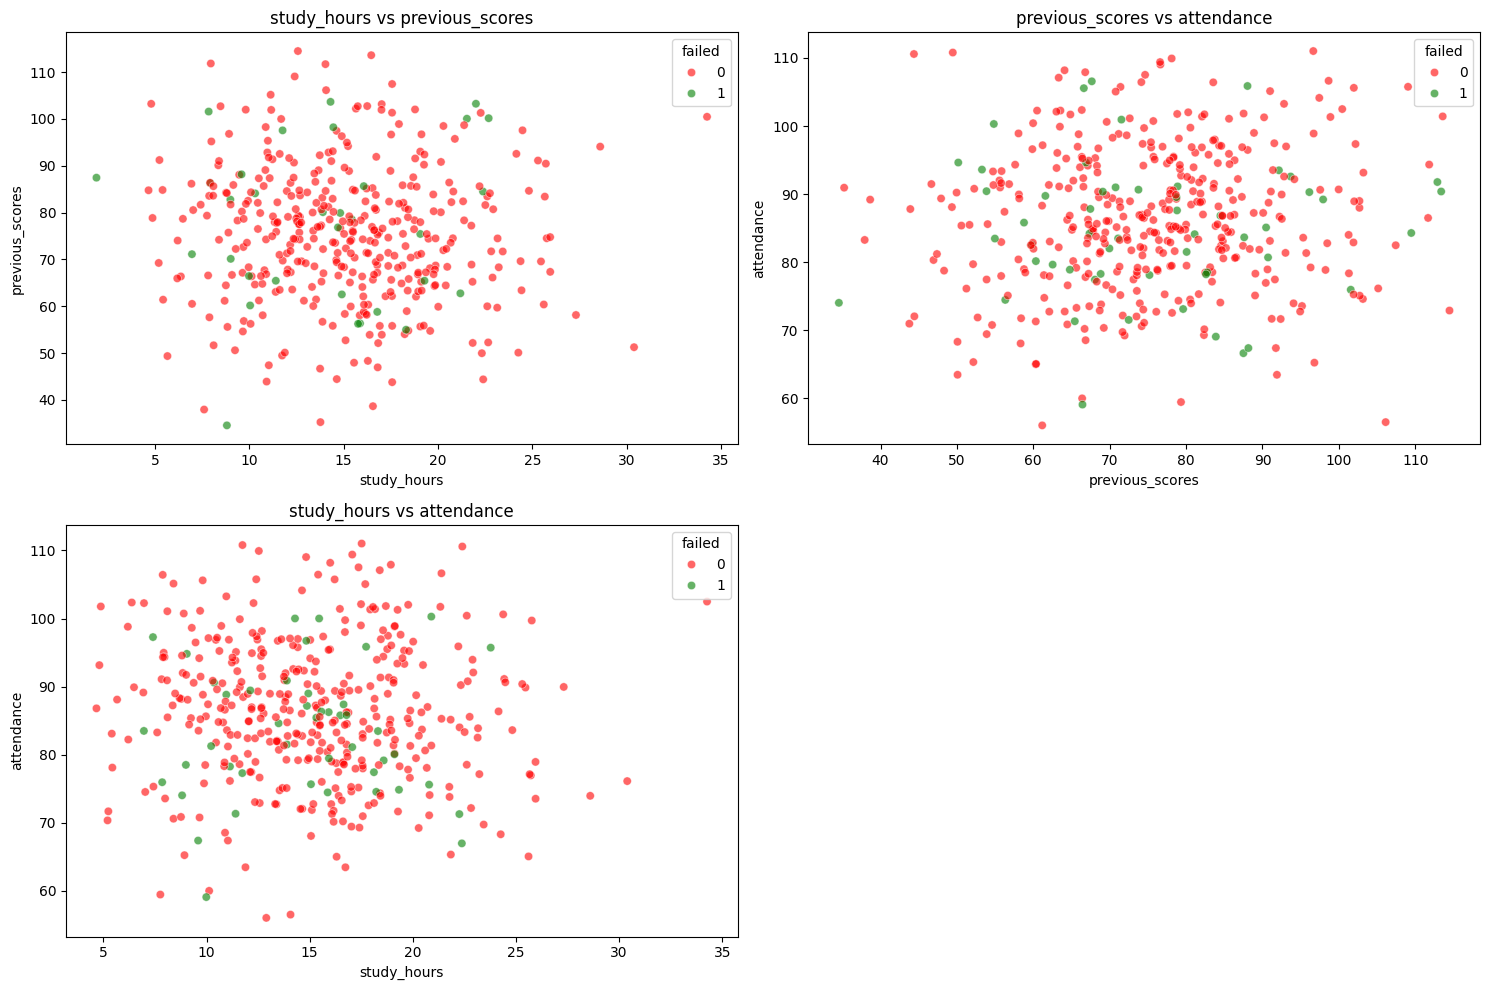

In [32]:
# Examine relationships between numeric features and with target
plt.figure(figsize=(15, 10))

# Create scatter plots between pairs of numerical features
# Colored by pass/fail outcome
for i, (x_feature, y_feature) in enumerate([(numeric_features[0], numeric_features[1]), 
                                          (numeric_features[1], numeric_features[2]), 
                                          (numeric_features[0], numeric_features[2])]):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(data=data, x=x_feature, y=y_feature, hue='failed', 
                    alpha=0.6, palette=['red', 'green'])
    plt.title(f'{x_feature} vs {y_feature}')

plt.tight_layout()
plt.show()

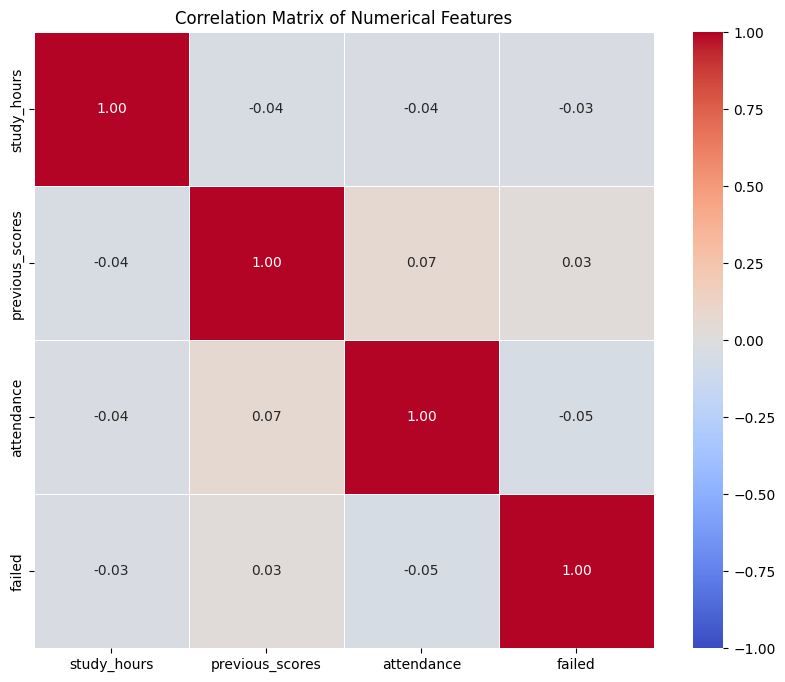

In [33]:
# Correlation analysis
plt.figure(figsize=(10, 8))
numeric_data = data[numeric_features + ['failed']].copy()
# Fill NaN for correlation calculation
numeric_data = numeric_data.fillna(numeric_data.median())
correlation_matrix = numeric_data.corr()

# Create heatmap with correlation values
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
            linewidths=0.5, fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


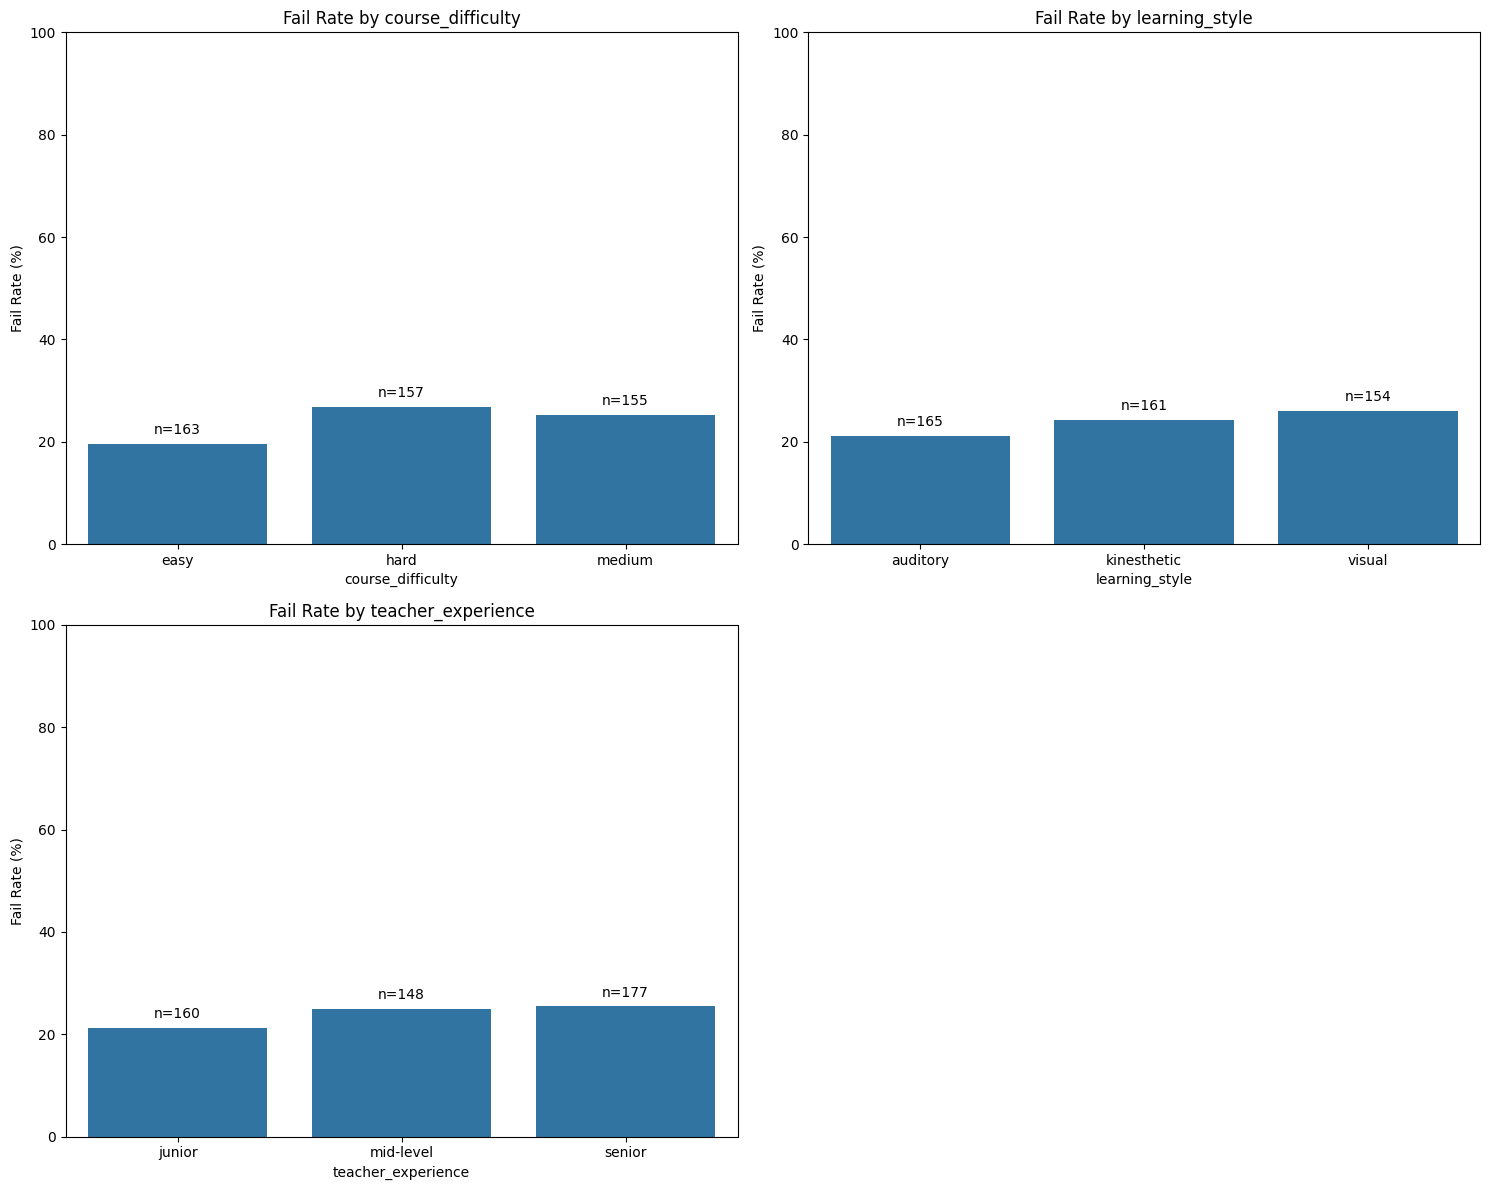

In [34]:
# Analyze categorical features
plt.figure(figsize=(15, 12))

# For each categorical feature
for i, feature in enumerate(categorical_features):
    plt.subplot(2, 2, i+1)
    
    # Calculate the percentage of failures for each category
    category_pass_rate = data.groupby(feature)['failed'].mean() * 100
    
    # Plot fail rate by category
    sns.barplot(x=category_pass_rate.index, y=category_pass_rate.values)
    plt.title(f'Fail Rate by {feature}')
    plt.ylabel('Fail Rate (%)')
    plt.ylim(0, 100)
    
    # Add count annotations on each bar
    counts = data[feature].value_counts()
    for j, p in enumerate(plt.gca().patches):
        if j < len(counts):
            category = category_pass_rate.index[j]
            count = counts.get(category, 0)
            plt.gca().annotate(f'n={count}', 
                              (p.get_x() + p.get_width()/2., p.get_height()), 
                              ha='center', va='center', xytext=(0, 10), 
                              textcoords='offset points')

plt.tight_layout()
plt.show()

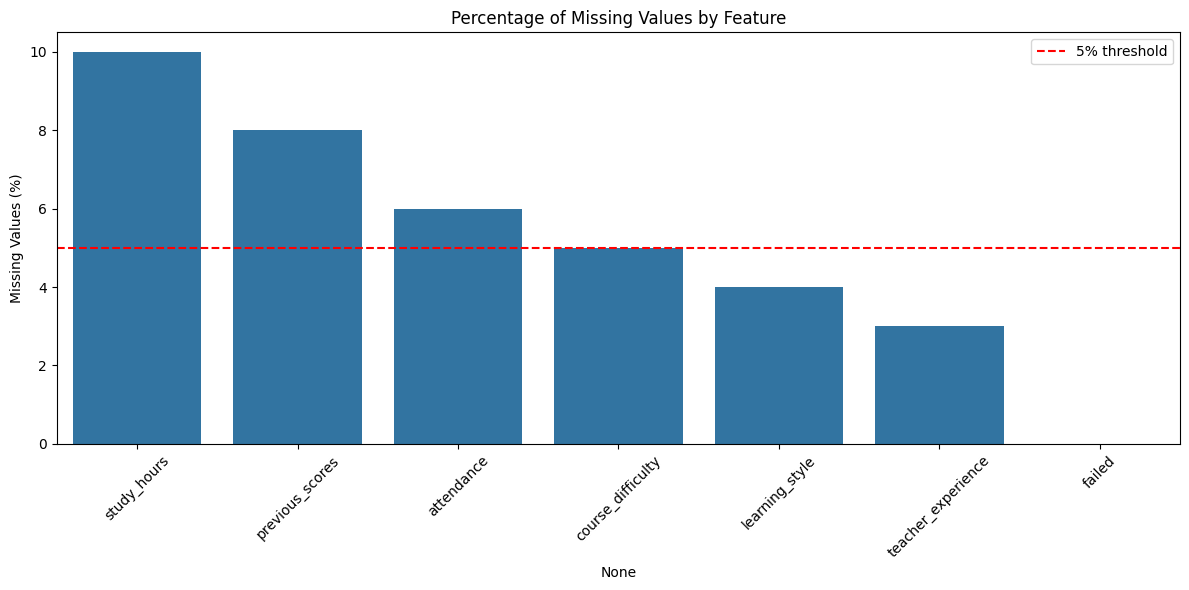

In [35]:
# Missing value analysis
plt.figure(figsize=(12, 6))

# Calculate percentage of missing values
missing_percentage = data.isnull().mean() * 100

# Create bar chart of missing values
sns.barplot(x=missing_percentage.index, y=missing_percentage.values)
plt.title('Percentage of Missing Values by Feature')
plt.ylabel('Missing Values (%)')
plt.xticks(rotation=45)
plt.axhline(y=5, color='r', linestyle='--', label='5% threshold')
plt.legend()
plt.tight_layout()
plt.show()

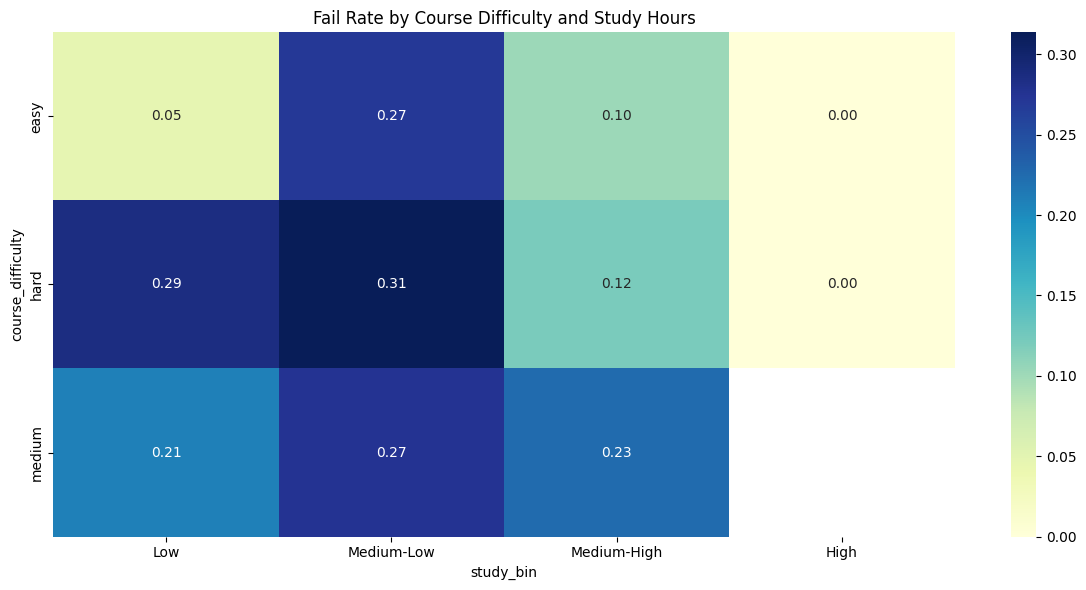

In [36]:
# Feature interaction exploration - example with study_hours and course_difficulty
plt.figure(figsize=(12, 6))
# Group by course difficulty and bin study hours
study_bins = pd.cut(data['study_hours'].fillna(data['study_hours'].median()), 
                    bins=4, labels=['Low', 'Medium-Low', 'Medium-High', 'High'])
interaction_data = pd.DataFrame({
    'course_difficulty': data['course_difficulty'],
    'study_bin': study_bins,
    'failed': data['failed']
})

# Plot fail rate by course difficulty and study hours
interaction_pivot = interaction_data.groupby(['course_difficulty', 'study_bin'], observed=False)['failed'].mean().reset_index()
interaction_pivot = interaction_pivot.pivot(index='course_difficulty', columns='study_bin', values='failed')
sns.heatmap(interaction_pivot, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Fail Rate by Course Difficulty and Study Hours')
plt.tight_layout()
plt.show()

In [37]:
# Output key findings from exploration
print("\n===== KEY FINDINGS FROM DATA EXPLORATION =====")
print("1. Numeric feature relationships with failing:")
for feature in numeric_features:
    correlation = data[[feature, 'failed']].corr().iloc[0, 1]
    print(f"   - {feature}: {correlation:.3f} correlation with failing")

print("\n2. Categorical feature impact:")
for feature in categorical_features:
    fail_rates = data.groupby(feature)['failed'].mean().sort_values(ascending=False)
    print(f"   - {feature}: Highest fail rate in '{fail_rates.index[0]}' ({fail_rates.iloc[0]:.2%}), " +
          f"lowest in '{fail_rates.index[-1]}' ({fail_rates.iloc[-1]:.2%})")

print("\n3. Missing value analysis:")
for feature in data.columns:
    missing_pct = data[feature].isnull().mean() * 100
    if missing_pct > 0:
        print(f"   - {feature}: {missing_pct:.1f}% missing")


===== KEY FINDINGS FROM DATA EXPLORATION =====
1. Numeric feature relationships with failing:
   - study_hours: -0.038 correlation with failing
   - previous_scores: 0.038 correlation with failing
   - attendance: -0.059 correlation with failing

2. Categorical feature impact:
   - course_difficulty: Highest fail rate in 'hard' (26.75%), lowest in 'easy' (19.63%)
   - learning_style: Highest fail rate in 'visual' (25.97%), lowest in 'auditory' (21.21%)
   - teacher_experience: Highest fail rate in 'senior' (25.42%), lowest in 'junior' (21.25%)

3. Missing value analysis:
   - study_hours: 10.0% missing
   - previous_scores: 8.0% missing
   - attendance: 6.0% missing
   - course_difficulty: 5.0% missing
   - learning_style: 4.0% missing
   - teacher_experience: 3.0% missing


### Step 3: Design and Implement Preprocessing Pipeline

In [38]:
# Create transformer for numerical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Create transformer for categorical features
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Combine preprocessing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])

### Step 4: Create Complete Model Pipeline

In [39]:
# Splitting the dataset into features and target variable
X = data.drop(columns=['failed'], axis=1)
y = data['failed']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

# Check shapes as quick sanity check
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (375, 6)
Test set shape: (125, 6)


In [40]:
# Create pipelines with different models
# 1. Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state=42))
])

# 2. Logistic Regression pipeline
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

### Step 5: Optimize and Tune the Pipeline

In [41]:
# Define parameter grids for each model
rf_param_grid = {
    # Preprocessing parameters
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    
    # Model parameters
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [10, 20, None],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__class_weight': ['balanced', None]
}

lr_param_grid = {
    # Preprocessing parameters
    'preprocessor__num__imputer__strategy': ['mean', 'median'],
    
    # Model parameters
    'classifier__C': [0.1, 1.0, 10.0],
    'classifier__class_weight': ['balanced', None],
    'classifier__solver': ['liblinear', 'saga']
}

# Define scoring metrics - we'll track multiple metrics
# but optimize for recall since missing at-risk students is costly
scoring = {
    'accuracy': 'accuracy',
    'recall': 'recall',
    'f1': 'f1'
}

# Create grid search for Random Forest
print("Starting Random Forest grid search...")
rf_grid_search = GridSearchCV(
    rf_pipeline,
    rf_param_grid,
    cv=5,  # 5-fold cross-validation
    scoring=scoring,
    refit='recall',  # Optimize for recall
    return_train_score=True
)
rf_grid_search.fit(X_train, y_train)

# Create grid search for Logistic Regression
print("\nStarting Logistic Regression grid search...")
lr_grid_search = GridSearchCV(
    lr_pipeline,
    lr_param_grid,
    cv=5,
    scoring=scoring,
    refit='recall',
    return_train_score=True
)
lr_grid_search.fit(X_train, y_train)

# Compare the models to select the best one:
# Get best parameters and scores
print("\n===== Grid Search Results =====")
print(f"Best Random Forest recall: {rf_grid_search.best_score_:.4f}")
print(f"Best Logistic Regression recall: {lr_grid_search.best_score_:.4f}")

# Select the best model based on recall
if rf_grid_search.best_score_ >= lr_grid_search.best_score_:
    best_model = rf_grid_search
    model_name = "Random Forest"
else:
    best_model = lr_grid_search
    model_name = "Logistic Regression"

print(f"\nBest model: {model_name}")
print("Best parameters:")
for param, value in best_model.best_params_.items():
    print(f"  {param}: {value}")

Starting Random Forest grid search...

Starting Logistic Regression grid search...

===== Grid Search Results =====
Best Random Forest recall: 0.6222
Best Logistic Regression recall: 0.5667

Best model: Random Forest
Best parameters:
  classifier__class_weight: balanced
  classifier__max_depth: 10
  classifier__min_samples_leaf: 4
  classifier__n_estimators: 100
  preprocessor__num__imputer__strategy: median


### Step 6: Final Model Evaluation and Understanding


===== Final Model Evaluation =====
Test set recall: 0.7000

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.92        95
           1       0.78      0.70      0.74        30

    accuracy                           0.88       125
   macro avg       0.84      0.82      0.83       125
weighted avg       0.88      0.88      0.88       125



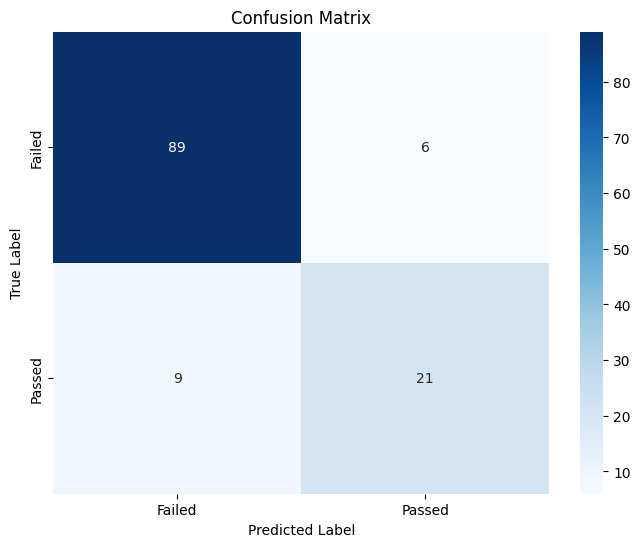

In [42]:
final_model = best_model.best_estimator_
y_pred = final_model.predict(X_test)

# Calculate test set metrics
test_recall = recall_score(y_test, y_pred)
print(f"\n===== Final Model Evaluation =====")
print(f"Test set recall: {test_recall:.4f}")

# Print detailed classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks([0.5, 1.5], ['Failed', 'Passed'])
plt.yticks([0.5, 1.5], ['Failed', 'Passed'])
plt.show()

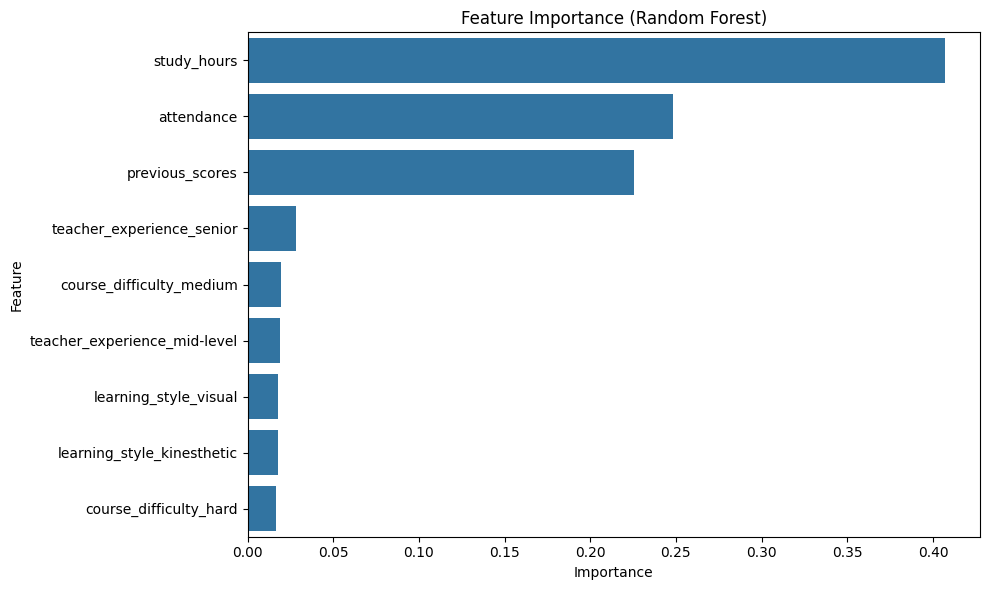


Top 5 most important features:
                     Feature  Importance
0                study_hours    0.407092
2                 attendance    0.248027
1            previous_scores    0.225394
8  teacher_experience_senior    0.028015
4   course_difficulty_medium    0.019775


In [43]:
# Analyze feature importance or coefficients based on model type
if model_name == "Random Forest":
    # Get the Random Forest model from the pipeline
    rf_model = final_model.named_steps['classifier']
    
    # Get feature names after preprocessing
    preprocessor = final_model.named_steps['preprocessor']
    
    # Get feature names
    feature_names = []
    feature_names.extend(numeric_features)
    
    # For categorical features, get the encoded feature names
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features)
    feature_names.extend(encoded_cat_features)
    
    # Get feature importances
    importances = rf_model.feature_importances_
    
    # Sort features by importance
    feature_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    feature_imp = feature_imp.sort_values('Importance', ascending=False)
    
    # Plot feature importances
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_imp)
    plt.title('Feature Importance (Random Forest)')
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 most important features:")
    print(feature_imp.head(5))
else:
    # For Logistic Regression, examine coefficients
    lr_model = final_model.named_steps['classifier']

    # Get feature names after preprocessing
    preprocessor = final_model.named_steps['preprocessor']
    
    # Get feature names using same approach
    feature_names = []
    feature_names.extend(numeric_features)
    
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    encoded_cat_features = cat_encoder.get_feature_names_out(categorical_features)
    feature_names.extend(encoded_cat_features)
    
    # Get coefficients
    coefficients = lr_model.coef_[0]
    
    # Create DataFrame of coefficients
    coef_df = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefficients
    })
    coef_df = coef_df.reindex(coef_df.Coefficient.abs().sort_values(ascending=False).index)
    
    # Plot coefficients
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Coefficient', y='Feature', data=coef_df)
    plt.title('Feature Coefficients (Logistic Regression)')
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print("\nTop 5 features with largest coefficients (absolute value):")
    print(coef_df.head(5))

In [44]:
# Summarize modeling decisions
print("\n===== Model Summary =====")
print(f"Selected model: {model_name}")
print("Business goal: Identify students at risk of failing courses")
print("Primary metric: Recall (minimize missed at-risk students)")
print(f"Test set performance: {test_recall:.4f} recall")
print("\nKey preprocessing decisions:")
print(f"  Numeric features imputation strategy: {best_model.best_params_.get('preprocessor__num__imputer__strategy', 'Not specified')}")
print("  Categorical features handled with one-hot encoding")
print("  All numeric features standardized to mean=0, variance=1")

print("\nModel successfully trained and evaluated!")


===== Model Summary =====
Selected model: Random Forest
Business goal: Identify students at risk of failing courses
Primary metric: Recall (minimize missed at-risk students)
Test set performance: 0.7000 recall

Key preprocessing decisions:
  Numeric features imputation strategy: median
  Categorical features handled with one-hot encoding
  All numeric features standardized to mean=0, variance=1

Model successfully trained and evaluated!
